<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-airnav/blob/main/NYC_Boston_Chicago_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 1: Install Compatible h3 and Required Libraries
!pip install h3==3.7.6
!pip install geopandas matplotlib seaborn scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.9 MB/s eta 0:00:00


In [3]:
# STEP 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.cluster import KMeans
import statsmodels.api as sm
from google.colab import files

#NYC Datasets

In [ ]:
# STEP 3: Upload Files
print("Upload: NYC_PM.csv, NYC_PM_Part1.csv, NYC_PM_Part2.csv, NYC_PM_Part3.csv, NYC_AQ.csv")
uploaded = files.upload()

Upload: NYC_PM.csv, NYC_PM_Part1.csv, NYC_PM_Part2.csv, NYC_PM_Part3.csv, NYC_AQ.csv


Saving NYC_PM.csv to NYC_PM.csv
Saving NYC_PM_Part3.csv to NYC_PM_Part3.csv
Saving NYC_PM_Part2.csv to NYC_PM_Part2.csv
Saving NYC_PM_Part1.csv to NYC_PM_Part1.csv
Saving NYC_AQ.csv to NYC_AQ.csv


In [ ]:
# STEP 4: Load and Merge PM Data
pm_main = pd.read_csv("NYC_PM.csv")
pm_parts = [pd.read_csv(f) for f in ["NYC_PM_Part1.csv", "NYC_PM_Part2.csv", "NYC_PM_Part3.csv"]]
pm_all = pd.concat([pm_main] + pm_parts, ignore_index=True)

In [ ]:
# STEP 5: Load AQ and Convert Time
aq = pd.read_csv("NYC_AQ.csv")
pm_all["datetime"] = pd.to_datetime(pm_all["time"], unit="s")
aq["datetime"] = pd.to_datetime(aq["time"], unit="s")

In [ ]:
# STEP 6: Merge Datasets
merged = pd.merge(pm_all, aq, on=["SensorID", "datetime"], suffixes=("_pm", "_aq"))

In [ ]:
# STEP 7: H3 Geohash Encoding
def latlon_to_h3(row, resolution=9):
    return h3.geo_to_h3(row["latitude_pm"], row["longitude_pm"], resolution)

merged["h3"] = merged.apply(latlon_to_h3, axis=1)

In [ ]:
# STEP 8: Normalize Features
scaler = StandardScaler()
merged[["pm25_pm_norm", "pm10_norm"]] = scaler.fit_transform(merged[["pm25_pm", "pm10"]].fillna(0))

In [ ]:
# STEP 9: Aggregate by H3 Cell
agg_by_h3 = merged.groupby("h3").agg({
    "pm25_pm": ["mean", "std"],
    "pm10": ["mean", "std"],
    "temperature_pm": "mean",
    "humidity_pm": "mean",
    "SensorID": "count"
}).reset_index()
agg_by_h3.columns = ['h3', 'pm25_mean', 'pm25_std', 'pm10_mean', 'pm10_std', 'temp_mean', 'humidity_mean', 'samples']

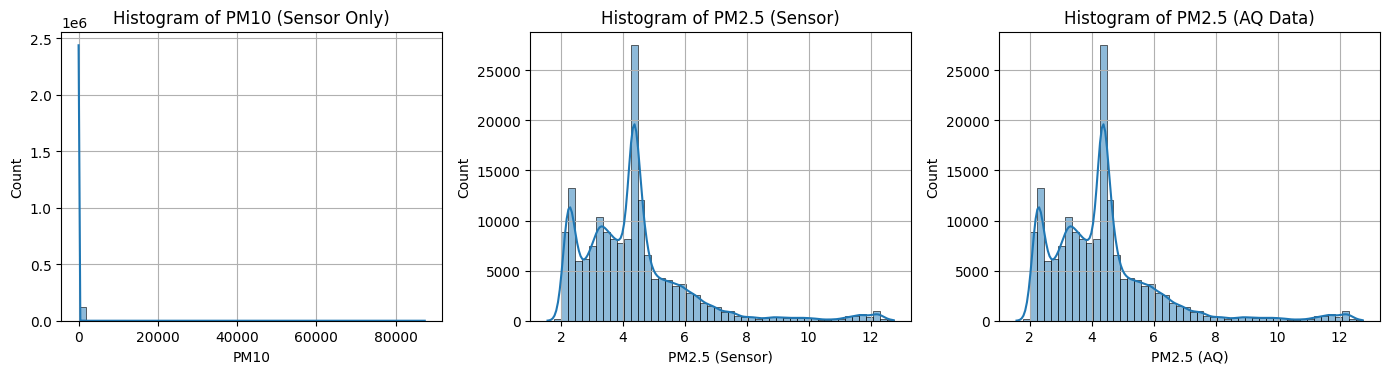

In [ ]:
# STEP 10: EDA - Histograms (using PM data only for PM10)

plt.figure(figsize=(14, 4))

# PM10 (from PM sensor only)
plt.subplot(1, 3, 1)
sns.histplot(pm_all["pm10"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM10 (Sensor Only)")
plt.xlabel("PM10")
plt.grid(True)

# PM2.5 from PM sensor
plt.subplot(1, 3, 2)
sns.histplot(merged["pm25_pm"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM2.5 (Sensor)")
plt.xlabel("PM2.5 (Sensor)")
plt.grid(True)

# PM2.5 from AQ source
plt.subplot(1, 3, 3)
sns.histplot(merged["pm25_aq"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM2.5 (AQ Data)")
plt.xlabel("PM2.5 (AQ)")
plt.grid(True)

plt.tight_layout()
plt.show()

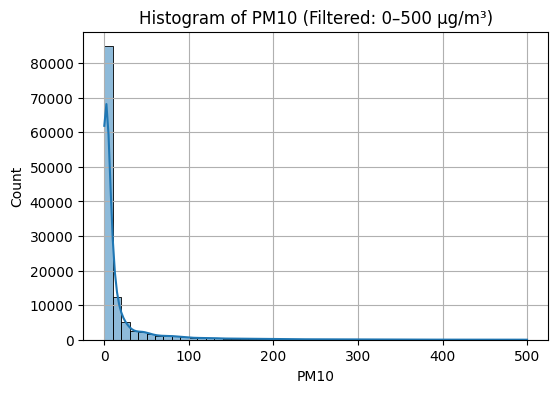

In [ ]:
plt.figure(figsize=(6, 4))
filtered_pm10 = pm_all["pm10"].dropna()
filtered_pm10 = filtered_pm10[(filtered_pm10 >= 0) & (filtered_pm10 <= 500)]  # Adjust if needed

sns.histplot(filtered_pm10, bins=50, kde=True)
plt.title("Histogram of PM10 (Filtered: 0–500 µg/m³)")
plt.xlabel("PM10")
plt.grid(True)
plt.show()

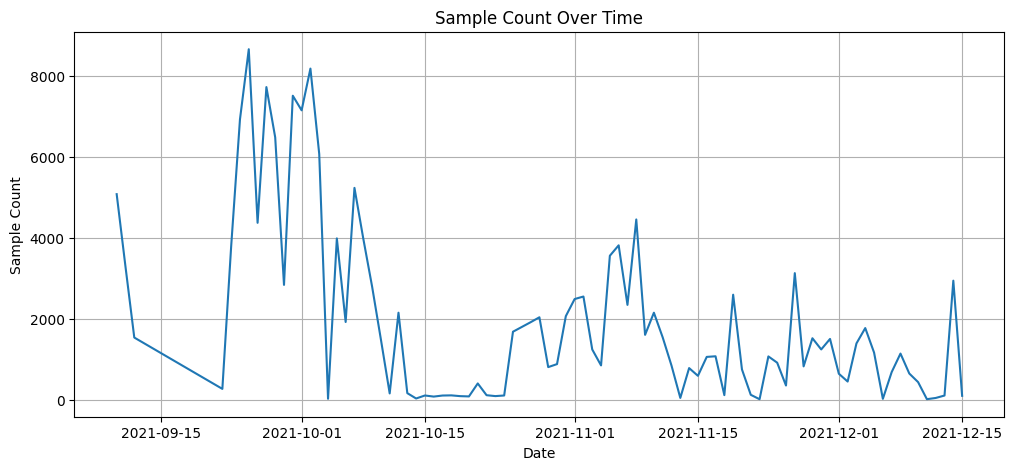

In [ ]:
# STEP 11: Time vs Sample Count
sample_over_time = merged.groupby(merged['datetime'].dt.date).size()

plt.figure(figsize=(12, 5))
sample_over_time.plot()
plt.title("Sample Count Over Time")
plt.xlabel("Date")
plt.ylabel("Sample Count")
plt.grid(True)
plt.show()

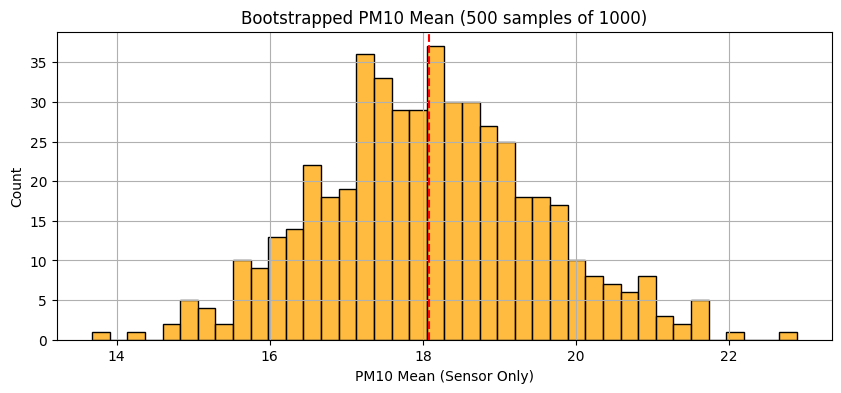

In [ ]:
# STEP 12: Bootstrapping Mean PM10 (from pm_all, filtered)
boot_means = [
    resample(
        pm_all["pm10"][(pm_all["pm10"] >= 0) & (pm_all["pm10"] <= 500)].dropna(),
        n_samples=1000
    ).mean()
    for _ in range(500)
]

plt.figure(figsize=(10, 4))
sns.histplot(boot_means, bins=40, color='orange')
plt.axvline(np.mean(boot_means), color='red', linestyle='--')
plt.title("Bootstrapped PM10 Mean (500 samples of 1000)")
plt.xlabel("PM10 Mean (Sensor Only)")
plt.grid(True)
plt.show()

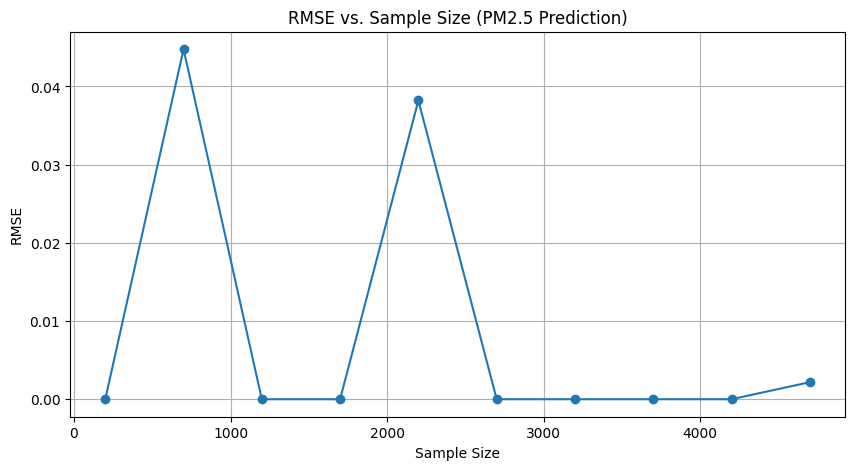

In [ ]:
# STEP 13: RMSE vs. Sample Size (PM2.5 Prediction)
samples = list(range(200, min(5000, len(merged)), 500))
rmses = []

for size in samples:
    sample = merged.sample(n=size)
    X = sample[["pm25_pm"]].fillna(0)
    y = sample["pm25_aq"].fillna(0)
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    rmses.append(rmse)

plt.figure(figsize=(10, 5))
plt.plot(samples, rmses, marker='o')
plt.title("RMSE vs. Sample Size (PM2.5 Prediction)")
plt.xlabel("Sample Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [ ]:
# STEP 14: Summary Statistics
summary_stats = merged[["pm25_pm", "pm25_aq"]].describe().T[["mean", "std", "min", "max"]]
summary_stats.loc["pm10_sensor"] = pm_all["pm10"][(pm_all["pm10"] >= 0) & (pm_all["pm10"] <= 500)].describe()[["mean", "std", "min", "max"]]

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


,mean,std,min,max
pm25_pm,4.310790,1.794630,1.568473,12.744419
pm25_aq,4.310790,1.794630,1.568473,12.744419
pm10_sensor,18.069142,45.071864,0.000000,499.650000


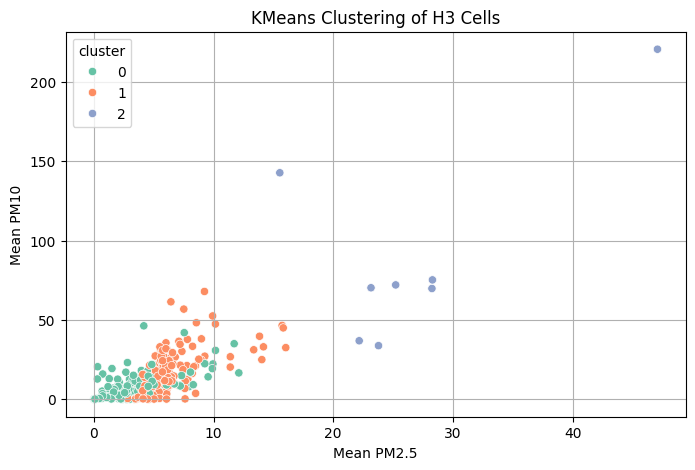

Cluster Profiles:


,pm25_mean,pm10_mean,temp_mean,humidity_mean,cluster
0,2.480485,5.268230,8.810725,54.818706,0
1,6.252662,16.854878,17.158615,54.079573,1
2,26.686068,90.179471,10.419346,77.511653,2


In [ ]:
# STEP 15: KMeans Clustering (on valid PM sensor data only)

# Recalculate H3 on pm_all to ensure consistency
pm_all["h3"] = pm_all.apply(lambda row: h3.geo_to_h3(row["latitude"], row["longitude"], 9), axis=1)

# Aggregate by H3 using only valid PM10 range
agg_by_h3 = pm_all.groupby("h3").agg({
    "pm25": "mean",  # Use "pm25_pm" if needed instead
    "pm10": lambda x: x[(x >= 0) & (x <= 500)].mean(),
    "temperature": "mean",
    "humidity": "mean"
}).reset_index()

agg_by_h3.columns = ["h3", "pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]

# Filter out NaNs before clustering
features = ["pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]
X = agg_by_h3[features].dropna().reset_index(drop=True)
X_scaled = StandardScaler().fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Create clustered DataFrame
agg_clustered = agg_by_h3.dropna(subset=features).reset_index(drop=True)
agg_clustered["cluster"] = cluster_labels

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=agg_clustered, x="pm25_mean", y="pm10_mean", hue="cluster", palette="Set2")
plt.title("KMeans Clustering of H3 Cells")
plt.xlabel("Mean PM2.5")
plt.ylabel("Mean PM10")
plt.grid(True)
plt.show()

# Show cluster centers
cluster_centers = pd.DataFrame(StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers["cluster"] = range(3)
print("Cluster Profiles:")
display(cluster_centers)

In [ ]:
# STEP 16: Multivariate Regression
df = pm_all[["pm10", "pm25", "temperature", "humidity"]].dropna()
df = df[(df["pm10"] >= 0) & (df["pm10"] <= 500)]

X_reg = sm.add_constant(df[["pm25", "temperature", "humidity"]])
y_reg = df["pm10"]

model = sm.OLS(y_reg, X_reg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm10   R-squared:                       0.322
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                 1.870e+04
Date:                Sun, 04 May 2025   Prob (F-statistic):               0.00
Time:                        10:49:11   Log-Likelihood:            -5.9520e+05
No. Observations:              118258   AIC:                         1.190e+06
Df Residuals:                  118254   BIC:                         1.190e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           8.8475      0.288     30.713      

In [ ]:
# STEP 17: Save for Comparison
summary_stats = df.describe()[["pm25", "pm10"]].T[["mean", "std", "min", "max"]]
summary_stats["city"] = "NYC"
agg_clustered["city"] = "NYC"

summary_stats.to_csv("nyc_summary_stats.csv", index=True)
agg_clustered.to_csv("nyc_aggregated_h3.csv", index=False)

print(" NYC analysis complete and saved.")

 NYC analysis complete and saved.



# Chicago Datasets



In [5]:
# STEP 18: Upload Chicago Datasets Files
print("Upload: chicago_eclipse_data_part_1.csv, chicago_eclipse_data_part_2.csv, chicago_eclipse_data_part_3.csv, chicago_eclipse_data_part_4.csv, chicago_eclipse_data_part_5.csv")
uploaded = files.upload()

Upload: chicago_eclipse_data_part_1.csv, chicago_eclipse_data_part_2.csv, chicago_eclipse_data_part_3.csv, chicago_eclipse_data_part_4.csv, chicago_eclipse_data_part_5.csv


Saving chicago_eclipse_data_part_5.csv to chicago_eclipse_data_part_5.csv
Saving chicago_eclipse_data_part_4.csv to chicago_eclipse_data_part_4.csv
Saving chicago_eclipse_data_part_3.csv to chicago_eclipse_data_part_3.csv
Saving chicago_eclipse_data_part_2.csv to chicago_eclipse_data_part_2.csv
Saving chicago_eclipse_data_part_1.csv to chicago_eclipse_data_part_1.csv


In [7]:
# STEP 19: Load and Merge Data
data_parts = [pd.read_csv(f) for f in ["chicago_eclipse_data_part_1.csv", "chicago_eclipse_data_part_2.csv", "chicago_eclipse_data_part_3.csv", "chicago_eclipse_data_part_4.csv", "chicago_eclipse_data_part_5.csv"]]
data_all = pd.concat(pm_parts, ignore_index=True)

In [20]:
# STEP 20: Convert Time
data_all["ReadingDateTimeUTC"] = pd.to_datetime(data_all["ReadingDateTimeUTC"])

In [21]:
# STEP 21: H3 Geohash Encoding
def latlon_to_h3(row, resolution=9):
    return h3.geo_to_h3(row["Latitude"], row["Longitude"], resolution)

data_all["h3"] = data_all.apply(latlon_to_h3, axis=1)

In [23]:
# STEP 22: Normalize Features
scaler = StandardScaler()
data_all[["pm25_norm" , "CalibratedPM25_norm"]] = scaler.fit_transform(data_all[["PM25", "CalibratedPM25"]].fillna(0))

In [25]:
# STEP 23: Aggregate by H3 Cell
agg_by_h3 = data_all.groupby("h3").agg({
    "PM25": ["mean", "std"],
    "CalibratedPM25": ["mean", "std"],
    "CalibratedO3": "mean",
    "CalibratedNO2": "mean",
    "CO": "mean",
    "BatteryLevel": "mean",
    "Temperature": "mean",
    "Humidity": "mean",
    "CellSignal": "mean",
    "DeviceId": "count"
}).reset_index()
agg_by_h3.columns = ['h3', 'pm25_mean', 'pm25_std', 'calibratedPM25_mean', 'calibratedPM25_std', 'calibratedO3_mean', 'calibratedNO2_mean', 'co_mean', 'batteryLevel_mean', 'temp_mean', 'humidity_mean', 'cellSignal_mean', 'samples']

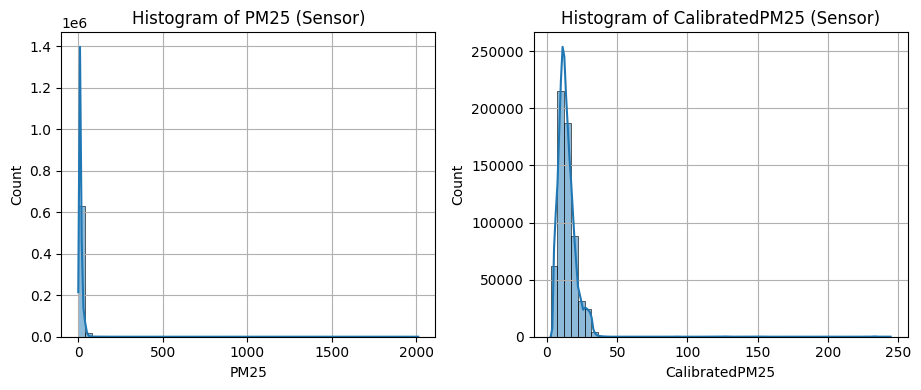

In [28]:
# STEP 24: EDA - Histograms (using PM data only for PM10)

plt.figure(figsize=(14, 4))

# PM25 (from PM sensor only)
plt.subplot(1, 3, 1)
sns.histplot(data_all["PM25"].dropna(), bins=50, kde=True)
plt.title("Histogram of PM25 (Sensor)")
plt.xlabel("PM25")
plt.grid(True)

# CalibratedPM25 (from PM sensor only)
plt.subplot(1, 3, 2)
sns.histplot(data_all["CalibratedPM25"].dropna(), bins=50, kde=True)
plt.title("Histogram of CalibratedPM25 (Sensor)")
plt.xlabel("CalibratedPM25")
plt.grid(True)

plt.tight_layout()
plt.show()

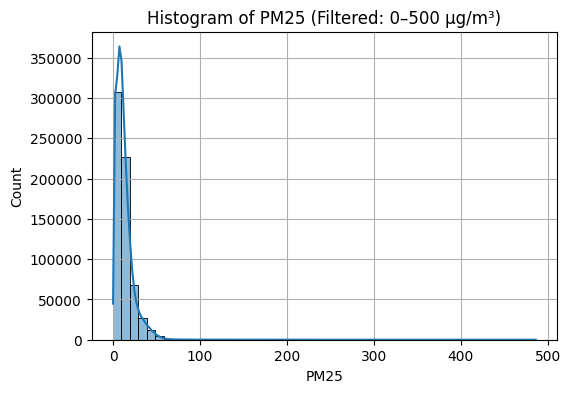

In [29]:
plt.figure(figsize=(6, 4))
filtered_PM25 = data_all["PM25"].dropna()
filtered_PM25 = filtered_PM25[(filtered_PM25 >= 0) & (filtered_PM25 <= 500)]  # Adjust if needed

sns.histplot(filtered_PM25, bins=50, kde=True)
plt.title("Histogram of PM25 (Filtered: 0–500 µg/m³)")
plt.xlabel("PM25")
plt.grid(True)
plt.show()

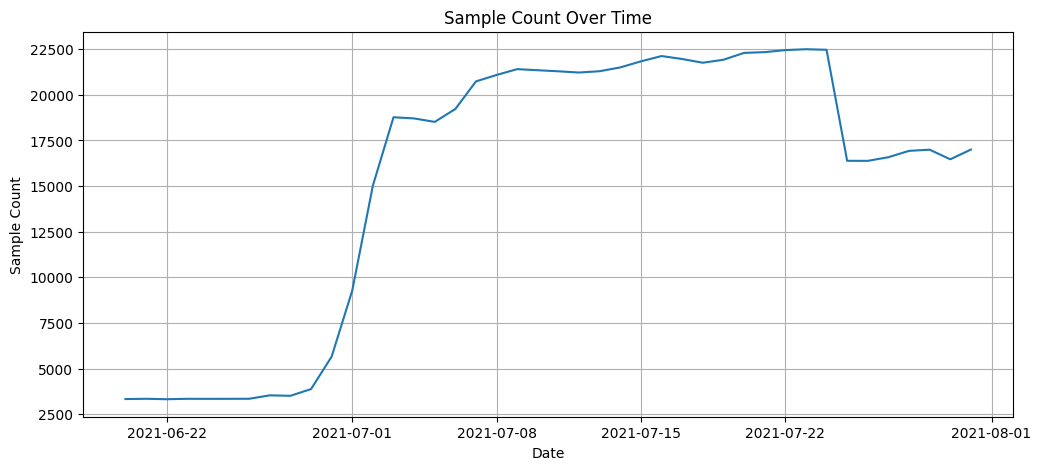

In [30]:
# STEP 25: Time vs Sample Count
sample_over_time = data_all.groupby(data_all['ReadingDateTimeUTC'].dt.date).size()

plt.figure(figsize=(12, 5))
sample_over_time.plot()
plt.title("Sample Count Over Time")
plt.xlabel("Date")
plt.ylabel("Sample Count")
plt.grid(True)
plt.show()

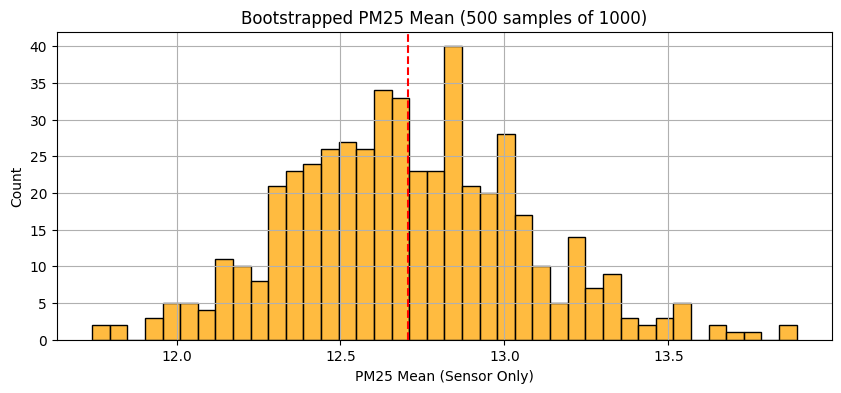

In [31]:
# STEP 26: Bootstrapping Mean PM10 (from data_all, filtered)
boot_means = [
    resample(
        data_all["PM25"][(data_all["PM25"] >= 0) & (data_all["PM25"] <= 500)].dropna(),
        n_samples=1000
    ).mean()
    for _ in range(500)
]

plt.figure(figsize=(10, 4))
sns.histplot(boot_means, bins=40, color='orange')
plt.axvline(np.mean(boot_means), color='red', linestyle='--')
plt.title("Bootstrapped PM25 Mean (500 samples of 1000)")
plt.xlabel("PM25 Mean (Sensor Only)")
plt.grid(True)
plt.show()

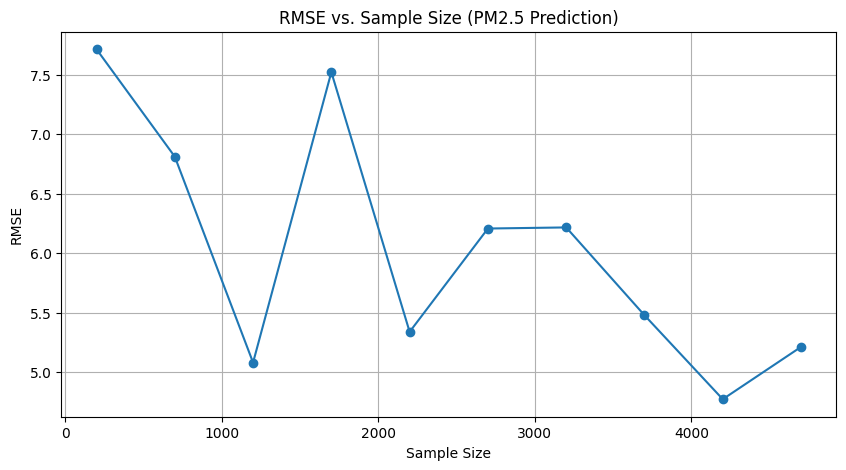

In [39]:
# STEP 27: RMSE vs. Sample Size (PM2.5 Prediction)
samples = list(range(200, min(5000, len(data_all)), 500))
rmses = []

for size in samples:
    sample = data_all.sample(n=size)
    X = sample[["PM25"]].fillna(0)
    y = sample["CalibratedPM25"].fillna(0)
    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    rmses.append(rmse)

plt.figure(figsize=(10, 5))
plt.plot(samples, rmses, marker='o')
plt.title("RMSE vs. Sample Size (PM2.5 Prediction)")
plt.xlabel("Sample Size")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

In [41]:
# STEP 28: Summary Statistics
summary_stats = data_all[["PM25", "CalibratedPM25"]].describe().T[["mean", "std", "min", "max"]]
summary_stats.loc["PM25"] = data_all["PM25"][(data_all["PM25"] >= 0) & (data_all["PM25"] <= 500)].describe()[["mean", "std", "min", "max"]]

print("Summary Statistics:")
display(summary_stats)

Summary Statistics:


,mean,std,min,max
PM25,12.725451,10.790649,0.00,486.344513
CalibratedPM25,14.347587,9.581892,2.64,244.580000


In [ ]:
# STEP 15: KMeans Clustering (on valid PM sensor data only)

# Recalculate H3 on pm_all to ensure consistency
pm_all["h3"] = pm_all.apply(lambda row: h3.geo_to_h3(row["latitude"], row["longitude"], 9), axis=1)

# Aggregate by H3 using only valid PM10 range
agg_by_h3 = pm_all.groupby("h3").agg({
    "pm25": "mean",  # Use "pm25_pm" if needed instead
    "pm10": lambda x: x[(x >= 0) & (x <= 500)].mean(),
    "temperature": "mean",
    "humidity": "mean"
}).reset_index()

agg_by_h3.columns = ["h3", "pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]

# Filter out NaNs before clustering
features = ["pm25_mean", "pm10_mean", "temp_mean", "humidity_mean"]
X = agg_by_h3[features].dropna().reset_index(drop=True)
X_scaled = StandardScaler().fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Create clustered DataFrame
agg_clustered = agg_by_h3.dropna(subset=features).reset_index(drop=True)
agg_clustered["cluster"] = cluster_labels

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=agg_clustered, x="pm25_mean", y="pm10_mean", hue="cluster", palette="Set2")
plt.title("KMeans Clustering of H3 Cells")
plt.xlabel("Mean PM2.5")
plt.ylabel("Mean PM10")
plt.grid(True)
plt.show()

# Show cluster centers
cluster_centers = pd.DataFrame(StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_), columns=features)
cluster_centers["cluster"] = range(3)
print("Cluster Profiles:")
display(cluster_centers)

#Boston Datasets

# Cross-City Comparison